# Preamble

In [50]:
import numpy as np
import pandas as pd
#import optuna 

from cluster_visuals import *
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.rcParams["figure.figsize"] = (8, 4.8)
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["axes.labelsize"] = 10

from sklearn.cluster import KMeans
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "random_state": 1,
    }
from sklearn.metrics import silhouette_score

import os
os.environ["OMP_NUM_THREADS"] = str(os.cpu_count()/4)

save = True

## Data Upload

In [51]:
# Load features from feats.csv
feats = np.array(np.loadtxt("./features.csv", delimiter=',', dtype=str))[:,0]

# Open the Excel file
excel_file = pd.ExcelFile("stats.xlsx")

adv = pd.read_excel(excel_file, sheet_name="advanced")
adv.index = [adv.PLAYER, adv.SEASON]
adv.drop(columns=["PLAYER", "SEASON"], inplace=True)

cols = []
# Iterate through each sheet and check for columns in feats
for sheet_name in excel_file.sheet_names:
    df = pd.read_excel(excel_file, sheet_name=sheet_name)

    matching_cols = [col for col in df.columns if col in feats]
    if matching_cols:
        if sheet_name == "bio":
            df.index = df.PLAYER
            df.drop(columns=["PLAYER"], inplace=True)
        else:
            df.index = [df.PLAYER, df.SEASON]
            df.drop(columns=["PLAYER", "SEASON"], inplace=True)
        
        for c in matching_cols:
            cols.append(df.loc[:, c])

data = pd.concat(cols, axis=1)
data = data[data.MIN > 720]
data.drop(columns=["MIN"], inplace=True)

#nan is used for players with less than 10 MPG (excluded already) and less than 10 possessions
#these are approximated to 0
data = data.fillna(0)

        

# Clustering

## Pre Processing

In [52]:
means = data.mean()
stds = data.std()
Z = (data - means) / (stds)
Z.head()

,,PER36_FGA_TRAD,PER36_3PA_TRAD,PER36_FTA_TRAD,EST.__USG%_ESTADV,EST.__PACE_ESTADV,PER36_POSS_P_ISO,PER36_FGA_P_ISO,PER36_POSS_P_TRANS,PER36_FGA_P_TRANS,PER36_POSS_P_BH,...,PER36_PASS_PAINT,PER36_PF_PAINT,PER36_SCREEN_ASSISTS,PER36_OFF_LOOSE_BALLS_RECOVERED,PER36_OFF_BOX_OUTS,PER36_FGA_RA,PER36_FGA_PAINT_NONRA,PER36_FGA_MID,PER36_FGA_CORNER3,PER36_FGA_ATB3
PLAYER,SEASON,,,,,,,,,,,,,,,,,,,,,
Shai Gilgeous-Alexander,2025,2.728334,0.291755,3.266231,2.671828,1.000078,4.649285,4.780405,-1.025634,-1.029557,2.717694,...,-0.605097,-0.644751,-0.644503,0.232202,-0.588922,1.055984,2.608412,2.540682,-1.360986,0.840438
Anthony Edwards,2025,1.978129,1.832241,1.620156,2.119781,-0.757381,2.999609,2.870179,0.974037,1.035259,2.226432,...,-0.849047,-0.493737,-0.716106,-0.202907,-0.519802,0.379182,0.253581,0.898624,-0.125054,2.123511
Nikola Jokić,2025,1.673495,-0.226732,1.672101,1.728006,0.965618,0.251447,0.250966,0.226994,0.055088,-0.146879,...,1.824243,1.187811,1.860192,4.005772,1.147956,1.153571,2.993954,0.142195,-1.358426,0.113510
Giannis Antetokounmpo,2025,2.124883,-1.582615,4.263651,2.796484,0.045044,-0.629119,-0.628508,-1.025634,-1.029557,0.393176,...,0.097775,1.533385,0.621948,1.845853,0.148140,4.152371,0.715109,2.262265,-1.550861,-1.258247
Jayson Tatum,2025,1.947483,1.765134,1.521915,2.030741,-0.777072,4.076949,4.320160,0.454169,0.417193,1.762618,...,-0.610140,-0.466693,-0.568797,0.259818,-0.475469,0.452694,0.011976,1.105305,-0.877077,2.373641


## Elbow Plot

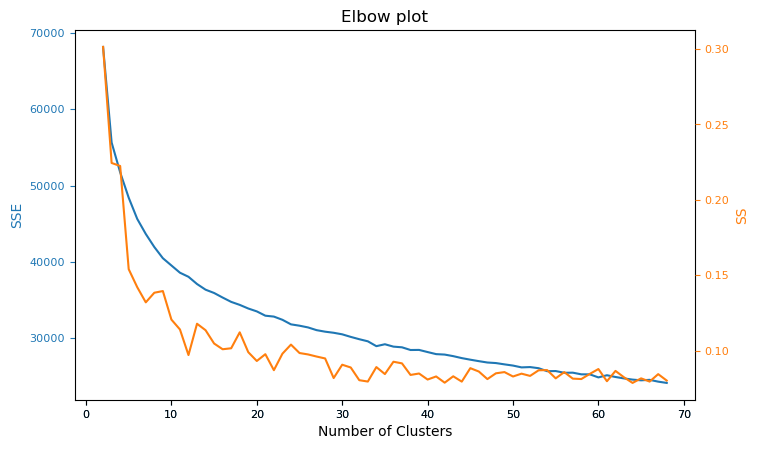

In [53]:
sse = []
sil = []
max_num = len(Z.columns)
for k in range(2, max_num):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(Z)
    sse.append(kmeans.inertia_)
    sil.append(silhouette_score(Z, kmeans.fit_predict(Z)))
    
#visualize results
fig=plt.figure()
ax=fig.add_subplot(111, label="1")
ax2=fig.add_subplot(111, label="2", frame_on=False)

ax.plot(np.arange(2, max_num), sse, color="C0")
ax.set_xlabel("Number of Clusters", color="black")
ax.set_ylabel("SSE", color="C0")
ax.tick_params(axis='x', colors="C0")
ax.tick_params(axis='y', colors="C0")

ax2.plot(np.arange(2, max_num), sil, color="C1")
ax2.yaxis.tick_right()
ax2.set_ylabel('SS', color="C1")       
ax2.yaxis.set_label_position('right') 
ax2.tick_params(axis='y', colors="C1")

plt.title("Elbow plot", fontsize=12)
plt.show()

In [54]:
sil

[0.30140589308061533,
 0.2244643246013106,
 0.22245847591420537,
 0.1540363747524255,
 0.14209570594881893,
 0.13206095843179785,
 0.1384273684542166,
 0.13954288032530437,
 0.12062504990926548,
 0.11407682140297083,
 0.09710857307163195,
 0.1178642339581948,
 0.11358147590046588,
 0.1047596020763565,
 0.10095358956771217,
 0.10160532900766403,
 0.11217884768397961,
 0.09902631804383508,
 0.09317468966374601,
 0.09767920525855418,
 0.0870773438385494,
 0.09800301355123643,
 0.10403959535406701,
 0.09845066792380204,
 0.09751968533015043,
 0.0961201494830348,
 0.09485159069274586,
 0.08186219424007386,
 0.09070104852762123,
 0.08885881076516676,
 0.0804377820756641,
 0.07953596547486978,
 0.08913485042806243,
 0.08449753791451106,
 0.09267574231276399,
 0.09159159226392452,
 0.0839241859074926,
 0.08487407272876599,
 0.08087170586674401,
 0.08291419638002837,
 0.0787847528220994,
 0.08302056578854737,
 0.07949223548742382,
 0.08841024506116664,
 0.08618250757907311,
 0.08116786891175612

## Clusters

In [55]:
n1=4
kmeans_n1 = KMeans(n1)
kmeans_n1.fit(Z)
centers_n1 = kmeans_n1.cluster_centers_
renorm_centers_n1 = np.array([( c*stds)+means for c in centers_n1])
data['CLUSTER'+ str(n1)] = kmeans_n1.labels_



In [56]:
n2=9
kmeans_n2 = KMeans(init="random", n_clusters=n2, n_init=10, random_state=1)
kmeans_n2.fit(Z)
centers_n2 = kmeans_n2.cluster_centers_
renorm_centers_n2 = np.array([( c*stds )+means for c in centers_n2])
data['CLUSTER'+ str(n2)] = kmeans_n2.labels_


## Saving

In [57]:
if save:
    writer = pd.ExcelWriter('./stats.xlsx', mode='a', engine='openpyxl',
                            if_sheet_exists="replace") 

    print(writer) 
    data[["CLUSTER"+str(n1), "CLUSTER"+str(n2)]].to_excel(
                                                        writer, 
                                                        sheet_name='kclusters'
                                                        )

    writer.close()

In [58]:
mean_diffs.columns

Index(['AVG_DRIB_PER_TOUCH_TOUCH', 'AVG_OREB_DISTANCE_OREB',
       'AVG_SEC_PER_TOUCH_TOUCH', 'AVG_SPEED_OFF_SANDD', 'CLUSTER4',
       'CLUSTER9', 'EST.__PACE_ESTADV', 'EST.__USG%_ESTADV',
       'OREB_CHANCE%_OREB', 'PER36_2PA_CANDS', 'PER36_2PA_PULLUP',
       'PER36_3PA_CANDS', 'PER36_3PA_PULLUP', 'PER36_3PA_TRAD',
       'PER36_CONTESTED_OREB_OREB', 'PER36_DEFERRED_OREB_CHANCES_OREB',
       'PER36_DRIVES_DRIVES', 'PER36_ELBOW_TOUCHES_ELBOW', 'PER36_FGA_ATB3',
       'PER36_FGA_CORNER3', 'PER36_FGA_DRIVES', 'PER36_FGA_ELBOW',
       'PER36_FGA_MID', 'PER36_FGA_PAINT_NONRA', 'PER36_FGA_POSTUP',
       'PER36_FGA_P_BH', 'PER36_FGA_P_CUT', 'PER36_FGA_P_HANDOFF',
       'PER36_FGA_P_ISO', 'PER36_FGA_P_MISC', 'PER36_FGA_P_OFFSCREEN',
       'PER36_FGA_P_PUTBACKS', 'PER36_FGA_P_ROLL', 'PER36_FGA_P_SPOTUP',
       'PER36_FGA_P_TRANS', 'PER36_FGA_RA', 'PER36_FGA_TRAD',
       'PER36_FRONT_CT_TOUCHES_TOUCH', 'PER36_FTA_DRIVES', 'PER36_FTA_ELBOW',
       'PER36_FTA_PAINT', 'PER36_FTA_POSTU

# General Informatio

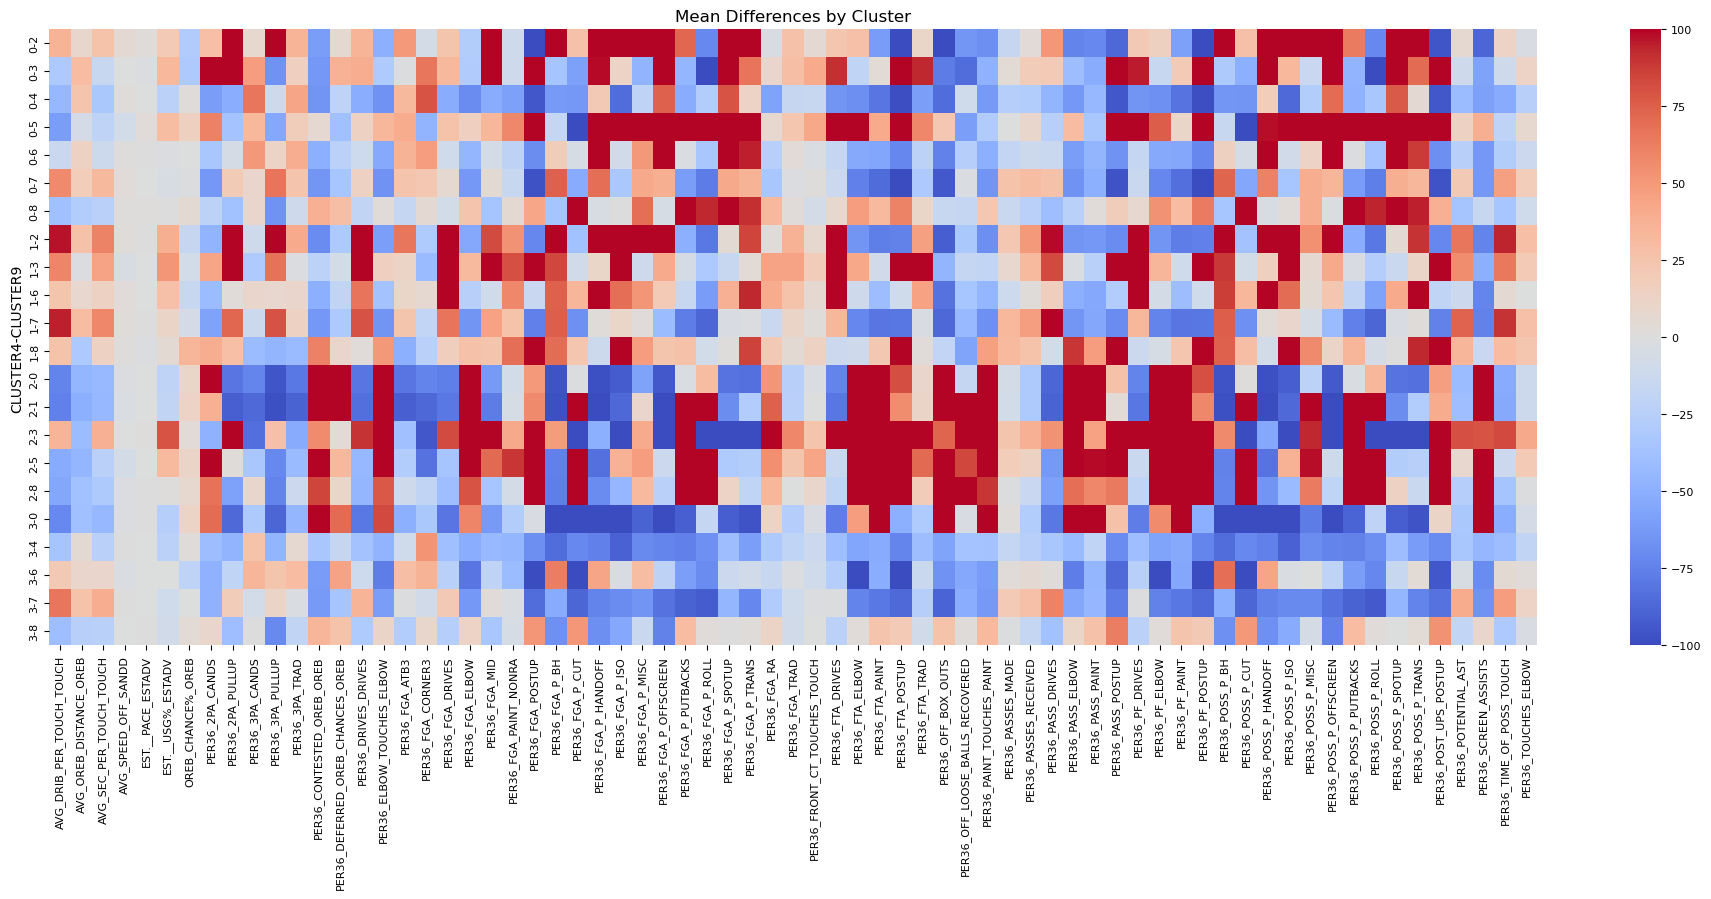

In [59]:
mean_df = (data.groupby(["CLUSTER"+str(n1), "CLUSTER"+str(n2)])).mean()
mean_diffs = 100*(mean_df - data.mean())/data.mean()

plt.figure(figsize=(24, 8))
sns.heatmap(mean_diffs.drop(columns=["CLUSTER"+str(n1), "CLUSTER"+str(n2)]), 
            cmap="coolwarm", 
            vmin = -100, vmax = 100,
            center=0, fmt=".1f")
plt.title("Mean Differences by Cluster")
plt.show()

In [60]:
data.groupby("CLUSTER"+str(n2)).mean()

,PER36_FGA_TRAD,PER36_3PA_TRAD,PER36_FTA_TRAD,EST.__USG%_ESTADV,EST.__PACE_ESTADV,PER36_POSS_P_ISO,PER36_FGA_P_ISO,PER36_POSS_P_TRANS,PER36_FGA_P_TRANS,PER36_POSS_P_BH,...,PER36_PF_PAINT,PER36_SCREEN_ASSISTS,PER36_OFF_LOOSE_BALLS_RECOVERED,PER36_OFF_BOX_OUTS,PER36_FGA_RA,PER36_FGA_PAINT_NONRA,PER36_FGA_MID,PER36_FGA_CORNER3,PER36_FGA_ATB3,CLUSTER4
CLUSTER9,,,,,,,,,,,,,,,,,,,,,
0,9.710951,1.319616,3.374782,15.385057,100.733563,0.061053,0.045231,0.301827,0.235589,0.067195,...,0.758108,4.320700,0.796614,0.814043,5.618412,2.235009,0.540145,0.426637,0.876755,2.126437
1,9.902839,0.539329,3.573619,15.764474,100.731447,0.122293,0.089434,1.439912,1.130332,0.037120,...,0.874507,4.763921,3.736319,0.982047,6.674000,2.367867,0.321158,0.177558,0.350884,2.000000
2,17.763208,7.404400,4.691032,26.934247,101.421027,2.875583,2.321939,3.878224,2.977376,8.040199,...,0.056296,0.335846,0.626331,0.017616,3.924881,3.813147,2.623677,0.957120,6.402799,0.986301
3,18.806335,5.079583,6.992059,29.735714,101.131571,3.341023,2.616032,2.183820,1.619227,3.958625,...,0.233282,0.696750,0.811458,0.120085,5.670754,4.441054,3.615655,0.784562,4.266814,1.014286
4,10.404158,5.714441,1.854394,15.070358,100.912736,0.090340,0.071812,0.861311,0.712132,0.351207,...,0.107266,0.706621,0.615869,0.088507,2.562425,1.329527,0.805252,2.098664,3.587208,2.794788
5,16.148800,3.082066,5.515625,25.665306,100.839184,1.313761,1.041947,1.633878,1.250369,0.563008,...,0.682123,4.097122,1.695926,0.636787,5.907807,4.710379,2.451312,0.248093,2.805311,1.959184
6,13.542741,7.244928,2.595057,19.368293,101.401854,0.830578,0.660362,3.768957,3.077801,2.517432,...,0.108585,0.470721,0.687736,0.054001,2.944575,2.032598,1.326809,1.995238,5.212468,0.053659
7,13.144522,5.588028,2.737350,19.762621,101.200825,0.629619,0.506283,1.382637,1.072848,2.517780,...,0.046552,0.390365,0.512126,0.025203,2.996498,2.778286,1.787907,1.197031,4.349218,1.859223
8,12.403397,4.401645,3.277840,18.589116,101.515918,0.530515,0.409141,2.297299,1.761483,0.787876,...,0.364629,1.747143,1.289770,0.307475,4.643566,2.409945,0.952216,1.365820,3.009780,2.224490


# Visualization

## Clusters N1

In [61]:
j = 2

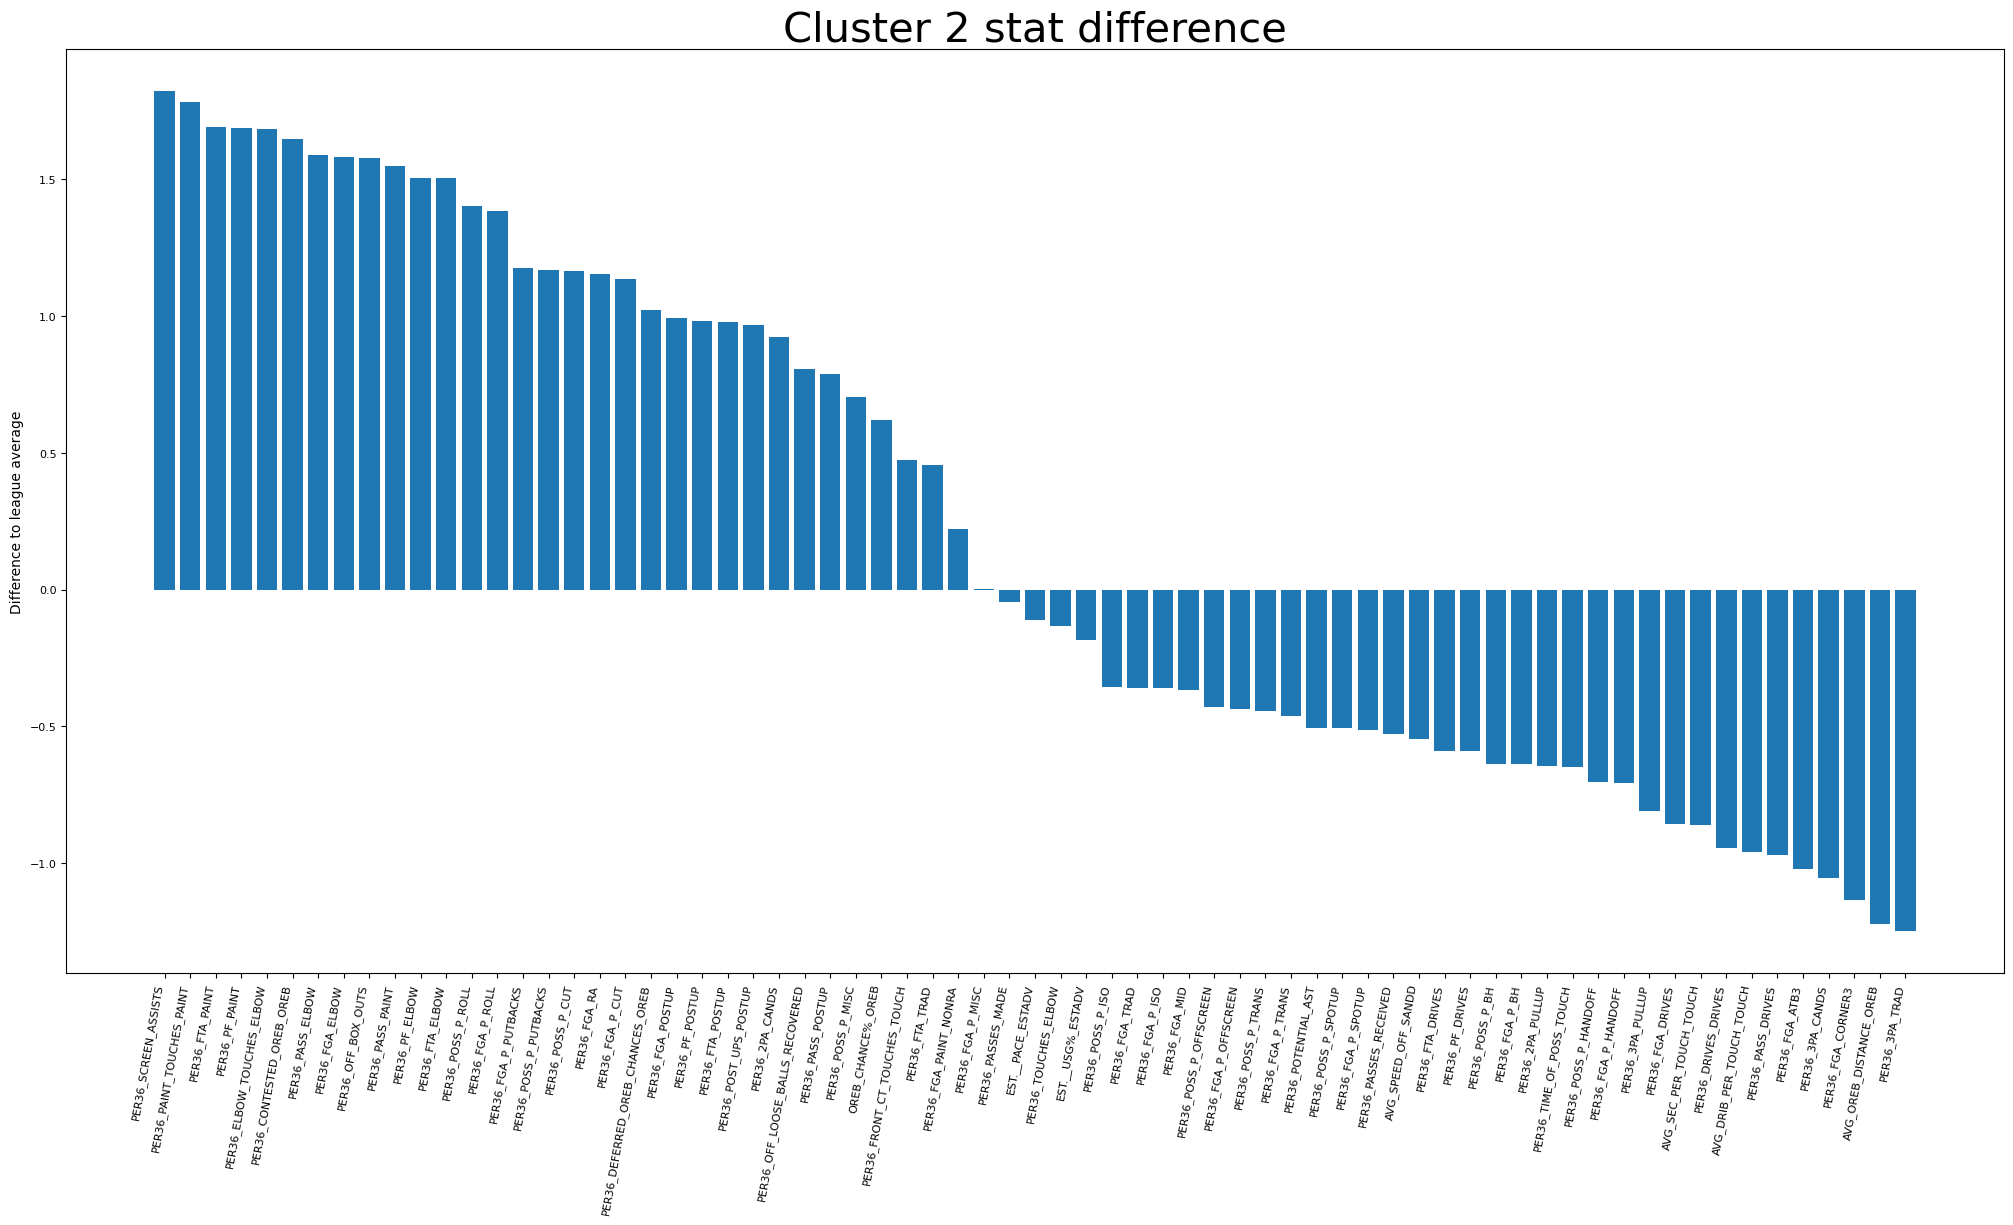

In [62]:
diff_plot(Z, j, centers_n1)

In [63]:
examples(Z, data, j, centers_n1, num=3, n_clusters=n1)

Closest to Cluster Average (Players in Cluster):
1º - ('Nic Claxton', 2024) - 0.223
2º - ('Wendell Carter Jr.', 2022) - 0.276
3º - ('Daniel Gafford', 2023) - 0.292


Farthest to Cluster Average (Players in Cluster):
3º - ('Nikola Jokić', 2022) - 4.306
2º - ('Joel Embiid', 2023) - 4.825
1º - ('Joel Embiid', 2022) - 6.977


Closest to Cluster Average (Players outside Cluster):
1º - ('Precious Achiuwa', 2022) - 0.605
2º - ('Al Horford', 2022) - 0.724
3º - ('Aaron Gordon', 2022) - 0.729


Farthest to Cluster Average (Players out Cluster):
3º - ('Shai Gilgeous-Alexander', 2022) - 6.284
2º - ('Klay Thompson', 2022) - 6.345
1º - ('Zach LaVine', 2024) - 7.180


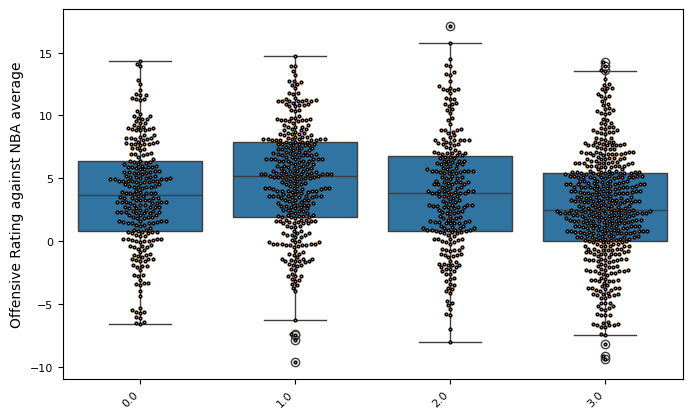

In [64]:
adv["CLUSTER"+str(n1)] = data["CLUSTER"+str(n1)]
adv["OFFRTG_DIFF"] = adv.OFFRTG_ADV-adv.OFFRTG_ADV.mean()

sns.boxplot(data=adv, y="OFFRTG_DIFF", x="CLUSTER"+str(n1))
sns.swarmplot(data=adv, y="OFFRTG_DIFF", x="CLUSTER"+str(n1),
              size=2, edgecolor='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Offensive Rating against NBA average")
plt.xlabel("")
plt.show()

## n2 Cluster

In [65]:
j = 2

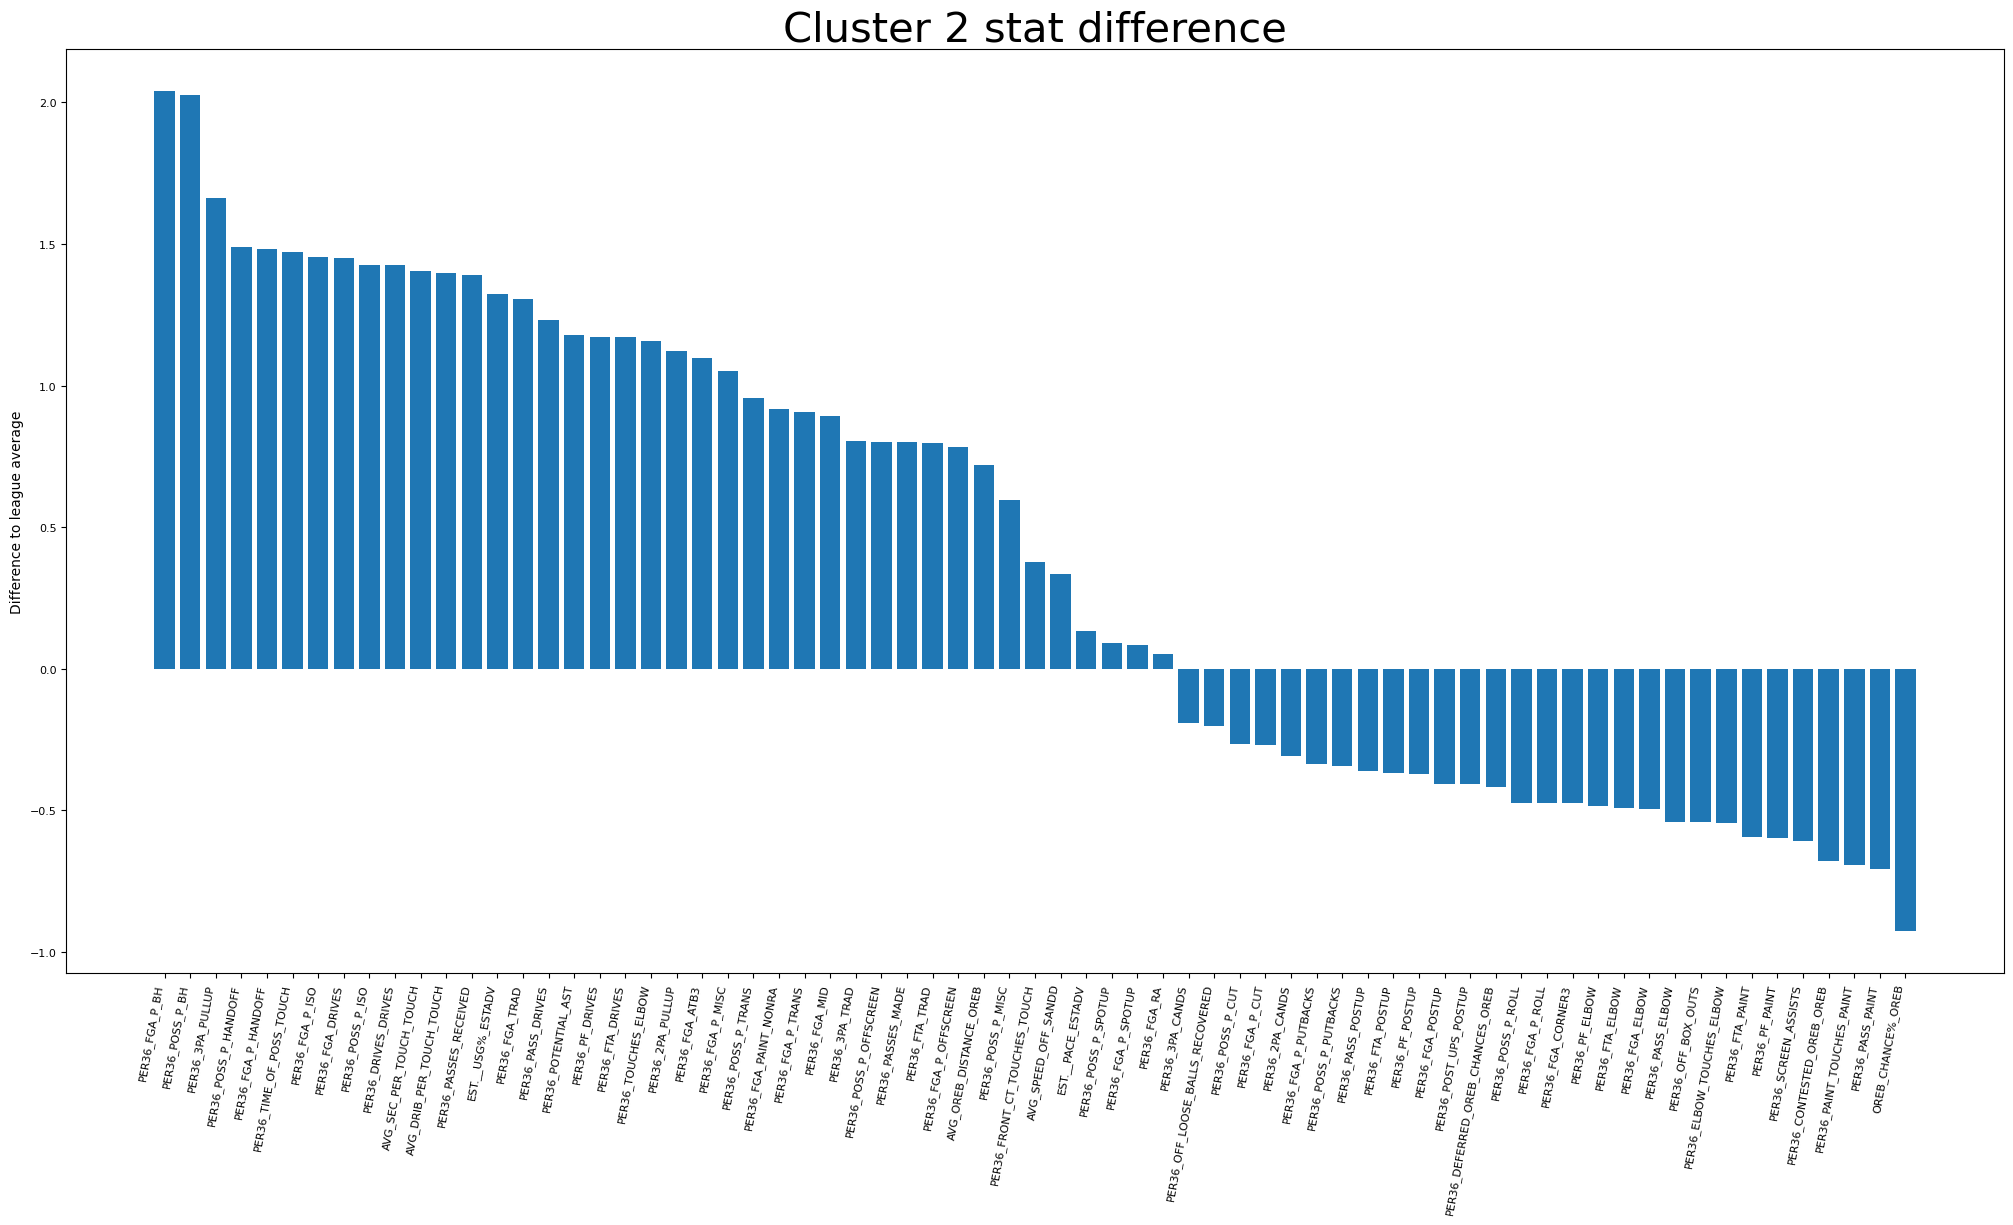

In [66]:
diff_plot(Z, j, centers_n2)

In [67]:
examples(Z, data, j=j, centers=centers_n2, num=3, n_clusters=n2)

Closest to Cluster Average (Players in Cluster):
1º - ('Tyrese Maxey', 2024) - 0.144
2º - ('Scoot Henderson', 2024) - 0.171
3º - ('Tyrese Maxey', 2023) - 0.174


Farthest to Cluster Average (Players in Cluster):
3º - ('James Harden', 2023) - 1.502
2º - ('Shai Gilgeous-Alexander', 2022) - 1.826
1º - ('Zach LaVine', 2024) - 2.768


Closest to Cluster Average (Players outside Cluster):
1º - ('Austin Reaves', 2024) - 0.326
2º - ('Cole Anthony', 2023) - 0.354
3º - ('Immanuel Quickley', 2024) - 0.361


Farthest to Cluster Average (Players out Cluster):
3º - ('Nikola Jokić', 2023) - 7.443
2º - ('Joel Embiid', 2023) - 7.809
1º - ('Joel Embiid', 2022) - 9.867


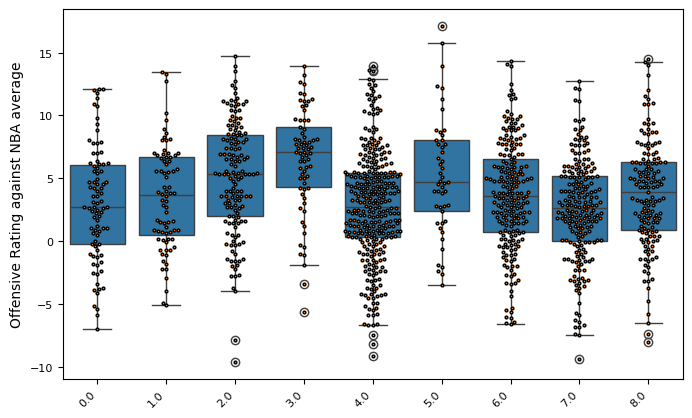

In [68]:
adv["CLUSTER"+str(n2)] = data["CLUSTER"+str(n2)]

sns.boxplot(data=adv, y="OFFRTG_DIFF", x="CLUSTER"+str(n2))
sns.swarmplot(data=adv, y="OFFRTG_DIFF", x="CLUSTER"+str(n2),
              size=2, edgecolor='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Offensive Rating against NBA average")
plt.xlabel("")
plt.show()